In [12]:
# Exploratory Data Analysis (EDA)

#In this notebook, we perform exploratory data analysis on the UNSW-NB15 dataset to understand its structure, class distribution, feature characteristics, and overall data quality before preprocessing and model training.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
from pathlib import Path

# Create report folders if they don't exist
REPORTS_DIR = Path("../reports")
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"
METRICS_DIR = REPORTS_DIR / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Reports folder:", REPORTS_DIR.resolve())
print("Figures folder:", FIGURES_DIR.resolve())

Reports folder: C:\Users\Krrish\OneDrive\Desktop\Safe-enterprise\reports
Figures folder: C:\Users\Krrish\OneDrive\Desktop\Safe-enterprise\reports\figures


In [15]:
TRAIN_PATH = "../datasets/raw/UNSW_NB15_training-set.csv"
TEST_PATH = "../datasets/raw/UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training Shape :", train_df.shape)
print("Testing Shape  :", test_df.shape)

Training Shape : (175341, 45)
Testing Shape  : (82332, 45)


In [16]:
## 1. Binary Class Distribution

In [17]:
print("=" * 70)
print("Binary Class Distribution")
print("=" * 70)

label_counts = train_df["label"].value_counts().sort_index()

label_counts.index = ["Normal (0)", "Attack (1)"]

display(label_counts)

print("\nPercentage Distribution")

label_percentage = (
    train_df["label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

label_percentage.index = ["Normal (0)", "Attack (1)"]

display(label_percentage)

Binary Class Distribution


Normal (0)     56000
Attack (1)    119341
Name: count, dtype: int64


Percentage Distribution


Normal (0)    31.94
Attack (1)    68.06
Name: proportion, dtype: float64

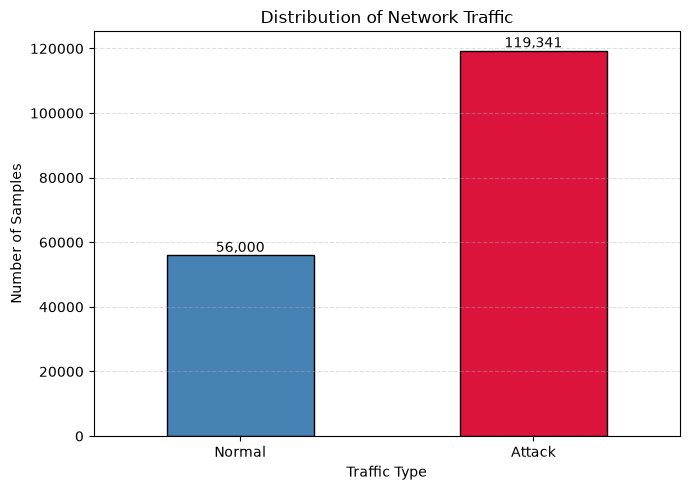

In [18]:
plt.figure(figsize=(7,5))

ax = train_df["label"].value_counts().sort_index().plot(
    kind="bar",
    color=["steelblue", "crimson"],
    edgecolor="black"
)

plt.title("Distribution of Network Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Samples")

plt.xticks(
    [0,1],
    ["Normal", "Attack"],
    rotation=0
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "../reports/figures/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
## 2. Attack Category Distribution

c:\Users\Krrish\OneDrive\Desktop\Safe-enterprise\notebooks


In [20]:
print("=" * 70)
print("Attack Category Distribution")
print("=" * 70)

attack_counts = train_df["attack_cat"].value_counts().sort_values(ascending=False)

display(attack_counts)

Attack Category Distribution


attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

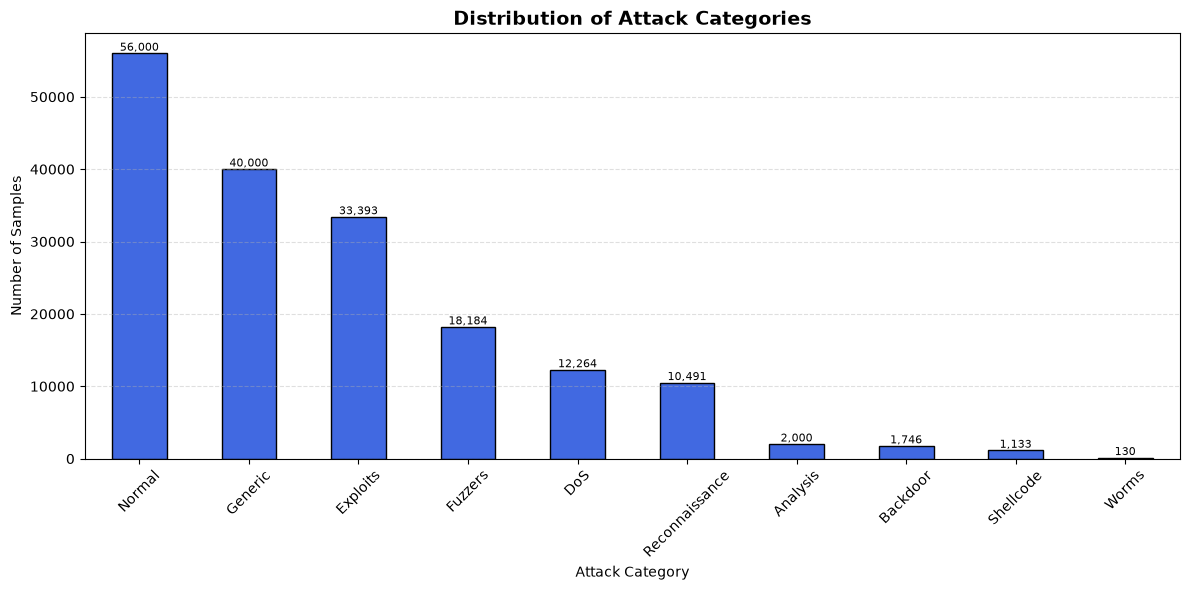

In [21]:
plt.figure(figsize=(12,6))

ax = attack_counts.plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title(
    "Distribution of Attack Categories",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Attack Category")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attack_category_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
## 3. Feature Type Analysis

In [23]:
categorical_columns = train_df.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("=" * 70)
print("Feature Type Summary")
print("=" * 70)

print(f"Categorical Features : {len(categorical_columns)}")
print(f"Numerical Features   : {len(numerical_columns)}")

print("\nCategorical Columns")
print(categorical_columns)

Feature Type Summary
Categorical Features : 4
Numerical Features   : 41

Categorical Columns
['proto', 'service', 'state', 'attack_cat']


C:\Users\Krrish\AppData\Local\Temp\ipykernel_11060\3204704789.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = train_df.select_dtypes(include=["object"]).columns.tolist()


In [24]:
print("=" * 70)
print("Unique Values in Categorical Columns")
print("=" * 70)

cardinality = pd.DataFrame({
    "Column": categorical_columns,
    "Unique Values": [train_df[col].nunique() for col in categorical_columns]
})

display(cardinality)

cardinality.to_csv(
    TABLES_DIR / "categorical_cardinality.csv",
    index=False
)

Unique Values in Categorical Columns


,Column,Unique Values
0,proto,133
1,service,13
2,state,9
3,attack_cat,10
